# Importing Lib's

In [3]:
!pip install tensorflow

In [4]:
import numpy as np
import pandas as pd

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

In [5]:
df = pd.read_csv('/content/metadata.csv')
df.head()

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


# Data Preprocessing

In [6]:
df = df.drop(['start_time', 'battery_id', 'test_id', 'uid', 'filename'], axis=1)
df.head()

,type,ambient_temperature,Capacity,Re,Rct
0,discharge,4,1.6743047446975208,NaN,NaN
1,impedance,24,NaN,0.05605783343888099,0.20097016584458333
2,charge,4,NaN,NaN,NaN
3,impedance,24,NaN,0.05319185850921101,0.16473399914864734
4,discharge,4,1.5243662105099023,NaN,NaN


In [7]:
df.isnull().sum()

,0
type,0
ambient_temperature,0
Capacity,4771
Re,5609
Rct,5609


In [8]:
# Filling Missing Values
df['Capacity'] = pd.to_numeric(df['Capacity'], errors= 'coerce')
df['Re'] = pd.to_numeric(df['Re'], errors= 'coerce')
df['Rct'] = pd.to_numeric(df['Rct'], errors= 'coerce')

# Filling Numerical Cols with mean()
df['Capacity'] = df['Capacity'].fillna(df['Capacity'].mean())
df['Re'] = df['Re'].fillna(df['Re'].mean())
df['Rct'] = df['Rct'].fillna(df['Rct'].mean())

In [9]:
df.isnull().sum()

,0
type,0
ambient_temperature,0
Capacity,0
Re,0
Rct,0


In [10]:
df.sample(5)

,type,ambient_temperature,Capacity,Re,Rct
1845,charge,24,1.326543,-4.976500e+11,1.055903e+12
313,charge,4,1.326543,-4.976500e+11,1.055903e+12
1387,charge,43,1.326543,-4.976500e+11,1.055903e+12
4750,impedance,24,1.326543,6.906647e-02,9.349096e-02
4239,charge,43,1.326543,-4.976500e+11,1.055903e+12


In [11]:
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])

In [12]:
df.sample(5)

,type,ambient_temperature,Capacity,Re,Rct
381,2,24,1.326543,7.857735e-02,2.292615e-01
1948,1,24,1.409738,-4.976500e+11,1.055903e+12
2168,1,24,1.333311,-4.976500e+11,1.055903e+12
3934,2,24,1.326543,1.032710e-01,1.271080e-01
3765,1,24,1.698467,-4.976500e+11,1.055903e+12


# Model Traning

In [13]:
x = df.drop('Capacity', axis= 1)
y = df['Capacity']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state= 42)
x_train.shape, x_test.shape

((6052, 4), (1513, 4))

In [14]:
scaler = MinMaxScaler()
x_train_scale = scaler.fit_transform(x_train)
x_test_scale = scaler.transform(x_test)

# Building ANN

In [15]:
model = Sequential()
model.add(Dense(64, activation= 'relu', input_shape= (x_train.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(32, activation= 'relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation= 'linear'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(optimizer= 'adam', loss= 'mean_squared_error', metrics= ['mse'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,433 (9.50 KB)

 Trainable params: 2,433 (9.50 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = model.fit(x_train_scale, y_train, epochs= 10, batch_size= 32, validation_split= 0.2)

Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.9575 - mse: 0.9575 - val_loss: 0.0657 - val_mse: 0.0657
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.1680 - mse: 0.1680 - val_loss: 0.0640 - val_mse: 0.0640
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1346 - mse: 0.1346 - val_loss: 0.0588 - val_mse: 0.0588
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1220 - mse: 0.1220 - val_loss: 0.0515 - val_mse: 0.0515
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1152 - mse: 0.1152 - val_loss: 0.0498 - val_mse: 0.0498
Epoch 6/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1002 - mse: 0.1002 - val_loss: 0.0482 - val_mse: 0.0482
Epoch 7/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0989 - mse: 0.0989 - val_loss: 0.0485 - val_mse: 0.0485
Epoch 8/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1028 - mse: 0.1028 - val_loss: 0.0482 - val_mse: 0.0482
Epoch 9/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - l

# Plotting

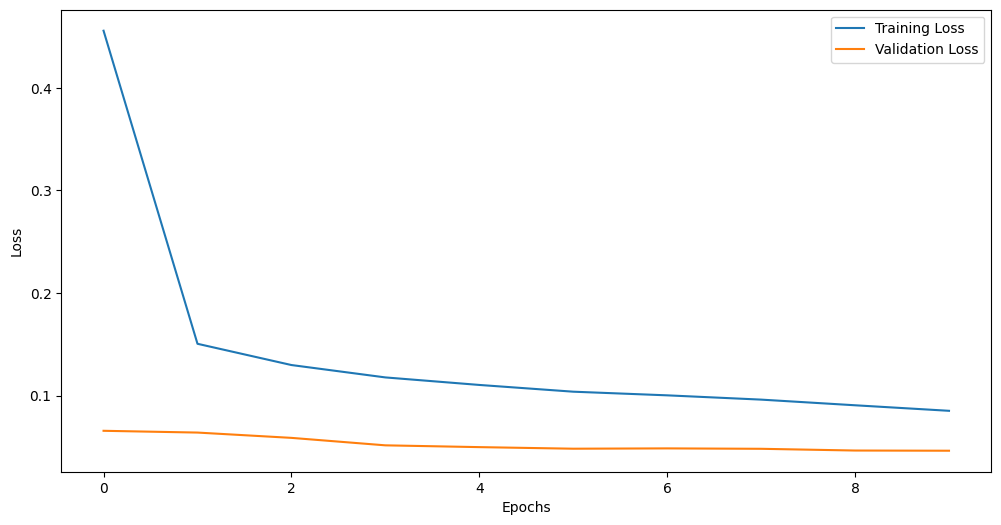

In [18]:
import matplotlib.pyplot as plt
plt.figure(figsize= (12, 6))
plt.plot(history.history['loss'], label= 'Training Loss')
plt.plot(history.history['val_loss'], label= 'Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [19]:
mse = model.evaluate(x_test_scale, y_test)
print(f'Mean Square Error: {mse[0]:.2f}')

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2379.2202 - mse: 2379.2202
Mean Square Error: 708.52


# Battery Life Prediction Function

In [20]:
def predict_battery_life(model, Capacity, Re, Rct, type_value):
    # Use the numerical type value directly
    input_data = np.array([[Capacity, Re, Rct, type_value]])
    input_data_scaled = scaler.transform(input_data)

    prediction = model.predict(input_data_scaled)
    return prediction[0][0]

In [21]:
# Test1
type_discharge_encoded = 1
Capacity = 1.674305
Re = -4.976500e+11
Rct = 1.055903e+12

prediction = predict_battery_life(model, Capacity, Re, Rct, type_discharge_encoded)
print(f"Predicted Battery Life: {prediction}")

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
Predicted Battery Life: 203200064.0


# Saving Model

In [22]:
import pickle

with open('battery_life_model.pkl', 'wb') as file:
    pickle.dump(model, file)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

In [23]:
model.save('battery_model.h5')